# Genshin Location NER with CRF

- IOB-tagged training data dari `genshin_ner_dataset.tsv`
- Gazetteer augmentation dari `genshin_areas.json`

## 1. Install Dependencies

In [34]:
import pkgutil
import subprocess
import sys

packages = {
    "nltk": "nltk",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "numpy": "numpy",
    "scipy": "scipy",
}

missing = [pip_name for module_name, pip_name in packages.items() if pkgutil.find_loader(module_name) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Installed:", ", ".join(missing))
else:
    print("All required packages are already installed.")



All required packages are already installed.


## 2. Set Paths and Load Files

In [35]:
from pathlib import Path
import sys

IN_COLAB = "google.colab" in sys.modules
BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "genshin_ner_dataset.tsv"
GAZETTEER_PATH = BASE_DIR / "genshin_areas.json"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

if IN_COLAB and (not DATASET_PATH.exists() or not GAZETTEER_PATH.exists()):
    from google.colab import files

    print("Upload `genshin_ner_dataset.tsv` and `genshin_areas.json` to continue.")
    files.upload()

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset file not found: {DATASET_PATH}")

if not GAZETTEER_PATH.exists():
    raise FileNotFoundError(f"Gazetteer file not found: {GAZETTEER_PATH}")


def preview_text_file(path: Path, max_lines: int = 5) -> list[str]:
    preview = []
    with open(path, "r", encoding="utf-8") as handle:
        for _ in range(max_lines):
            line = handle.readline()
            if not line:
                break
            preview.append(line.rstrip("\n"))
    return preview


def validate_uploaded_dataset_file(path: Path) -> None:
    preview = preview_text_file(path, max_lines=5)
    joined_preview = " ".join(preview).lower()

    if any(marker in joined_preview for marker in ['"cells"', '"metadata"', '"nbformat"']):
        raise ValueError(
            "The uploaded `genshin_ner_dataset.tsv` looks like a Jupyter notebook JSON file, not a token-tag TSV file. "
            "Please re-upload the real dataset file where each line looks like `token<TAB>tag`."
        )

    print("Dataset file preview:")
    for line in preview:
        print(line)


validate_uploaded_dataset_file(DATASET_PATH)

print(f"Dataset: {DATASET_PATH}")
print(f"Gazetteer: {GAZETTEER_PATH}")
print(f"Outputs: {OUTPUT_DIR}")



Dataset file preview:
Does	O
anyone	O
know	O
how	O
to	O
Dataset: d:\Fajrul\Kuliah\Skripsi\Chatbot\genshin_ner_dataset.tsv
Gazetteer: d:\Fajrul\Kuliah\Skripsi\Chatbot\genshin_areas.json
Outputs: d:\Fajrul\Kuliah\Skripsi\Chatbot\outputs


## 3. Import Libraries and Define Global Settings

In [36]:
import json
import pickle
import random
import re

import matplotlib.pyplot as plt
import nltk
try:
    from IPython.display import Image, display
except ImportError:
    Image = None

    def display(obj):
        print(obj)
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

LABELS = ["O", "B-LOC", "I-LOC"]
LOCATION_CONNECTORS = {"of", "de", "al", "al-", "the"}
ALIAS_MAP = {
    # === MONDSTADT ===
    "mondo": "mondstadt",
    "mond": "mondstadt",
    "mondstat": "mondstadt", # Typo yang sangat sering terjadi
    "dragon spine": "dragonspine",
    "stormterror": "stormterror's lair",
    "dvalin lair": "stormterror's lair",
    "dvalin's lair": "stormterror's lair",
    
    # === LIYUE ===
    "chasm": "the chasm",
    "chasm underground": "the chasm: underground mines",
    "underground mines": "the chasm: underground mines",
    "chasm maw": "the chasm's maw",
    "liyue city": "liyue harbor",
    "chenyu": "chenyu vale: upper vale", # Biasanya player menyebut chenyu merujuk ke area utamanya
    
    # === INAZUMA ===
    "enka": "enkanomiya",
    "watatsumi": "watatsumi island",
    "narukami": "narukami island",
    "seirai": "seirai island",
    "yashiori": "yashiori island",
    "tsurumi": "tsurumi island",
    "narukami shrine": "grand narukami shrine (subarea)",
    "grand narukami shrine": "grand narukami shrine (subarea)",
    
    # === SUMERU ===
    "sumeru desert": "hypostyle desert",
    "hadramaveth": "desert of hadramaveth",
    "king deshret": "the mausoleum of king deshret",
    "mausoleum": "the mausoleum of king deshret",
    "pyramid": "the mausoleum of king deshret", # Sering disebut pyramid di komunitas
    "farakhkert": "realm of farakhkert",
    "oasis": "vourukasha oasis",
    "vanarana": "vanarana (subarea)",
    "old vanarana": "lost nursery",
    
    # === FONTAINE ===
    "fri": "fontaine research institute of kinetic energy engineering region",
    "research institute": "fontaine research institute of kinetic energy engineering region",
    "kinetic institute": "fontaine research institute of kinetic energy engineering region",
    "meropide": "fortress of meropide",
    "prison": "fortress of meropide", # Sering disebut prison/penjara
    "remuria": "sea of bygone eras", # Remuria adalah nama lore dari map ini
    "bygone eras": "sea of bygone eras",
    "court of fontaine": "court of fontaine region",
    
    # === NATLAN ===
    "stadium": "stadium of the sacred flame",
    "scions": "\"scions of the canopy\"",
    "canopy": "\"scions of the canopy\"",
    "echoes": "\"children of echoes\"",
    "springs": "\"people of the springs\"",
    "night wind": "\"masters of the night-wind\"",
    "flower feather": "\"flower-feather clan\"",
    "collective": "\"collective of plenty\"",
    "night kingdom": "night kingdom",
    
    # === NOD-KRAI ===
    "nod krai": "nod-krai",
    "nodkrai": "nod-krai",
    "kuuvahki": "kuuvahki experimental design bureau",
    "design bureau": "kuuvahki experimental design bureau",
    "research institute nod krai": "special territory research institute",
    "special territory": "special territory research institute"
}
_ABBREV_RE = re.compile(r"^[A-Z][a-z]{0,3}\.$")

print("Imports and global settings loaded.")



Imports and global settings loaded.


## 4. Gazetteer Preparation

In [37]:
def normalize_name(name: str) -> str:
    name = name.lower().strip()
    if name.startswith('"') and name.endswith('"'):
        name = name[1:-1]
    name = re.sub(r"\s*\([^)]*\)\s*$", "", name)
    name = name.strip("[]")
    name = re.sub(r'\b(mt|st|dr|ft)\.', r'\1', name)
    name = name.strip(".:,;!?")
    return name.strip()

def load_gazetteer(json_path: str) -> tuple[set[str], set[str]]:
    with open(json_path, "r", encoding="utf-8") as handle:
        data = json.load(handle)

    names = flatten_gazetteer(data)
    for expansion in ALIAS_MAP.values():
        names.add(normalize_name(expansion))

    return names, build_token_set(names)

def flatten_gazetteer(data: dict) -> set[str]:
    names: set[str] = set()
    for region_name, region_data in data.items():
        names.add(normalize_name(region_name))
        if not isinstance(region_data, dict):
            continue
        for area_name, area_data in region_data.get("areas", {}).items():
            names.add(normalize_name(area_name))
            if isinstance(area_data, dict):
                for sub_area in area_data.get("sub_areas", []):
                    cleaned = normalize_name(sub_area)
                    if cleaned:
                        names.add(cleaned)
    names.discard("")
    return names

def build_token_set(names: set[str]) -> set[str]:
    tokens: set[str] = set()
    for name in names:
        for word in name.split():
            cleaned = word.strip(':.,;"\'()')
            if cleaned and len(cleaned) > 1:
                tokens.add(cleaned)
    return tokens

with open(GAZETTEER_PATH, "r", encoding="utf-8") as handle:
    gazetteer_raw = json.load(handle)

sample_region_name = next(iter(gazetteer_raw))
sample_region = gazetteer_raw[sample_region_name]
gazetteer_names, gazetteer_tokens = load_gazetteer(str(GAZETTEER_PATH))

print("Gazetteer sebelum flattening:")
print({
    sample_region_name: {
        "type": sample_region.get("type"),
        "sample_areas": list(sample_region.get("areas", {}).keys())[:3],
    }
})
print("\nFlattened gazetteer sample (5 nama pertama):")
print(sorted(gazetteer_names)[:5])
print("\nFlattened gazetteer token sample (5 token pertama):")
print(sorted(gazetteer_tokens)[:5])



Gazetteer sebelum flattening:
{'Mondstadt': {'type': 'Region', 'sample_areas': ['Brightcrown Mountains', 'Galesong Hill', 'Starfell Valley']}}

Flattened gazetteer sample (5 nama pertama):
['a lonely place', 'a very bright place', 'a very warm place', 'aaru village', 'abdju pit']

Flattened gazetteer token sample (5 token pertama):
['aaru', 'abdju', 'academy', 'ad-hoc', "adeptus's"]


## 5. Tokenization and Text Normalization

In [38]:
def ensure_pos_tagger() -> None:
    try:
        nltk.data.find("taggers/averaged_perceptron_tagger_eng")
    except LookupError:
        try:
            nltk.download("averaged_perceptron_tagger_eng", quiet=True)
        except Exception:
            nltk.download("averaged_perceptron_tagger", quiet=True)

def tokenize_locations(text: str) -> list[str]:
    for old, new in (("\u201c", '"'), ("\u201d", '"'), ("\u2018", "'"), ("\u2019", "'")):
        text = text.replace(old, new)

    tokens: list[str] = []
    for token in text.split():
        while len(token) > 1 and token[0] == '"' and token[-1] == '"':
            token = token[1:-1]
        token = token.strip('"')

        if token.startswith("(") and token.endswith(")"):
            continue
        token = re.sub(r"\([^)]*\)$", "", token)

        if not _ABBREV_RE.match(token):
            token = token.rstrip("?!,;.")

        if token:
            tokens.append(token)

    merged_tokens: list[str] = []
    idx = 0
    while idx < len(tokens):
        if idx + 1 < len(tokens) and tokens[idx] == "Mt." and tokens[idx + 1] and tokens[idx + 1][0].isalpha():
            merged_tokens.append(f"{tokens[idx]} {tokens[idx + 1]}")
            idx += 2
            continue
        merged_tokens.append(tokens[idx])
        idx += 1

    return merged_tokens

def get_pos_tags(tokens: list[str]) -> list[str]:
    ensure_pos_tagger()
    return [tag for _, tag in nltk.pos_tag(tokens)]


def normalize_token(token: str) -> str:
    return normalize_name(token).strip(':.,;!?"')

def build_sentence_lookup(tokens: list[str]) -> set[str]:
    cleaned = [normalize_token(token) for token in tokens if normalize_token(token)]
    phrases: set[str] = set()
    for start in range(len(cleaned)):
        current = []
        for end in range(start, min(len(cleaned), start + 5)):
            current.append(cleaned[end])
            phrases.add(" ".join(current))
    return phrases

sample_text = 'How to enter "The Chasm: Underground Mines?'
sample_tokens = tokenize_locations(sample_text)

print("Tokenization before:")
print(sample_text)
print("\nTokenization after:")
print(sample_tokens)
print("\nNormalized token preview:")
print([(token, normalize_token(token)) for token in sample_tokens[:14]])



Tokenization before:
How to enter "The Chasm: Underground Mines?

Tokenization after:
['How', 'to', 'enter', 'The', 'Chasm:', 'Underground', 'Mines']

Normalized token preview:
[('How', 'how'), ('to', 'to'), ('enter', 'enter'), ('The', 'the'), ('Chasm:', 'chasm'), ('Underground', 'underground'), ('Mines', 'mines')]


## 6. Feature Engineering

In [39]:
def is_fuzzy_gazetteer_token(normalized: str, gazetteer_tokens: set[str]) -> bool:
    if len(normalized) < 4:
        return False
        
    import nltk
    max_ed = 2
    norm_len = len(normalized)
    
    for gaz_token in gazetteer_tokens:
        if abs(norm_len - len(gaz_token)) > max_ed:
            continue
        if nltk.edit_distance(normalized, gaz_token) <= max_ed:
            return True
    return False

def word2features(
    sentence: list[str],
    pos_tags: list[str],
    index: int,
    gazetteer_names: set[str],
    gazetteer_tokens: set[str],
    sentence_lookup: set[str],
) -> dict[str, object]:
    word = sentence[index]
    normalized = normalize_token(word)
    postag = pos_tags[index]

    in_token_set = normalized in gazetteer_tokens
    in_full_name = normalized in gazetteer_names
    in_sentence_gazetteer = any(
        phrase in gazetteer_names for phrase in sentence_lookup if normalized and normalized in phrase.split()
    )
    
    is_fuzzy = in_token_set or is_fuzzy_gazetteer_token(normalized, gazetteer_tokens)

    features = {
        "bias": 1.0,
        "word.prefix2": normalized[:2],
        "word.prefix3": normalized[:3],
        "word.suffix2": normalized[-2:],
        "word.suffix3": normalized[-3:],
        "postag": postag,
        "postag[:2]": postag[:2],
    }

    if word.isdigit():
        features["word.isdigit()"] = True
    if index == 0:
        features["is_sentence_start"] = True
    if index == len(sentence) - 1:
        features["is_sentence_end"] = True
    if normalized in LOCATION_CONNECTORS:
        features["is_location_connector"] = True
    if is_fuzzy or in_full_name:
        features["is_in_genshin_map"] = True
    if is_fuzzy:
        features["gazetteer_word_overlap"] = True
    if is_fuzzy or in_sentence_gazetteer:
        features["gazetteer_phrase_overlap"] = True

    if len(normalized) >= 4:
        for i in range(len(normalized) - 2):
            trigram = normalized[i:i+3]
            features[f"word.trigram:{trigram}"] = True

    if index > 0:
        prev_word = sentence[index - 1]
        prev_norm = normalize_token(prev_word)
        features.update({
            "-1:postag": pos_tags[index - 1],
            "-1:postag[:2]": pos_tags[index - 1][:2],
        })
        if prev_norm in LOCATION_CONNECTORS:
            features["-1:is_connector"] = True
        if prev_norm in gazetteer_tokens:
            features["-1:gazetteer_word_overlap"] = True
    else:
        features["BOS"] = True

    if index < len(sentence) - 1:
        next_word = sentence[index + 1]
        next_norm = normalize_token(next_word)
        features.update({
            "+1:postag": pos_tags[index + 1],
            "+1:postag[:2]": pos_tags[index + 1][:2],
        })
        if next_norm in LOCATION_CONNECTORS:
            features["+1:is_connector"] = True
        if next_norm in gazetteer_tokens:
            features["+1:gazetteer_word_overlap"] = True
    else:
        features["EOS"] = True

    return features


def sent2features(sentence: list[str], gazetteer_names: set[str], gazetteer_tokens: set[str]) -> list[dict[str, object]]:
    pos_tags = get_pos_tags(sentence)
    sentence_lookup = build_sentence_lookup(sentence)
    return [
        word2features(sentence, pos_tags, idx, gazetteer_names, gazetteer_tokens, sentence_lookup)
        for idx in range(len(sentence))
    ]

feature_sentence = tokenize_locations("How to enter \"The Chasm: Underground Mines?")

feature_index = feature_sentence.index("Chasm:")
feature_output = sent2features(feature_sentence, gazetteer_names, gazetteer_tokens)

print("Feature engineering before:")
print(feature_sentence)
print("\nFeature engineering target token:")
print(feature_sentence[feature_index])
print("\nFeature engineering after (selected token feature dictionary):")
print(feature_output[feature_index])



Feature engineering before:
['How', 'to', 'enter', 'The', 'Chasm:', 'Underground', 'Mines']

Feature engineering target token:
Chasm:

Feature engineering after (selected token feature dictionary):
{'bias': 1.0, 'word.prefix2': 'ch', 'word.prefix3': 'cha', 'word.suffix2': 'sm', 'word.suffix3': 'asm', 'postag': 'NNP', 'postag[:2]': 'NN', 'is_in_genshin_map': True, 'gazetteer_word_overlap': True, 'gazetteer_phrase_overlap': True, 'word.trigram:cha': True, 'word.trigram:has': True, 'word.trigram:asm': True, '-1:postag': 'DT', '-1:postag[:2]': 'DT', '-1:is_connector': True, '-1:gazetteer_word_overlap': True, '+1:postag': 'NNP', '+1:postag[:2]': 'NN', '+1:gazetteer_word_overlap': True}


## 7. Dataset Parsing and Gazetteer Augmentation

In [40]:
def parse_tsv_dataset(dataset_path: str) -> list[tuple[list[str], list[str]]]:
    sentences = []
    tokens = []
    tags = []
    skipped_lines = []

    with open(dataset_path, "r", encoding="utf-8") as handle:
        for line_number, raw_line in enumerate(handle, start=1):
            line = raw_line.strip()
            if not line:
                if tokens:
                    sentences.append((tokens, tags))
                    tokens, tags = [], []
                continue

            if "\t" in line:
                parts = line.split("\t", 1)
            else:
                parts = line.rsplit(None, 1)

            if len(parts) != 2:
                skipped_lines.append((line_number, line))
                continue

            token, tag = parts[0].strip(), parts[1].strip()
            if tag not in {"O", "B-LOC", "I-LOC"}:
                skipped_lines.append((line_number, line))
                continue

            tokens.append(token)
            tags.append(tag)

    if tokens:
        sentences.append((tokens, tags))

    if skipped_lines:
        print("Skipped malformed dataset lines:", skipped_lines[:5])

    return sentences


def extract_first_location_span(tags: list[str]) -> tuple[int, int] | None:
    start_index = None
    end_index = None

    for index, tag in enumerate(tags):
        if tag == "B-LOC":
            if start_index is not None:
                break
            start_index = index
            end_index = index + 1
        elif tag == "I-LOC" and start_index is not None:
            end_index = index + 1
        elif start_index is not None:
            break

    if start_index is None or end_index is None:
        return None
    return start_index, end_index


def build_augmented_sentence(template_tokens: list[str], template_tags: list[str], location_name: str) -> tuple[list[str], list[str]] | None:
    location_span = extract_first_location_span(template_tags)
    if location_span is None:
        return None

    location_tokens = tokenize_locations(location_name)
    if not location_tokens:
        return None

    start_index, end_index = location_span
    augmented_tokens = template_tokens[:start_index] + location_tokens + template_tokens[end_index:]
    augmented_tags = template_tags[:start_index] + ["B-LOC"] + ["I-LOC"] * (len(location_tokens) - 1) + template_tags[end_index:]
    return augmented_tokens, augmented_tags


def augment_with_gazetteer(
    sentences,
    gazetteer_names,
    max_examples: int = 10000,
    random_state: int = 42,
    templates_per_area: int = 3,
):
    rng = random.Random(random_state)
    candidates = [
        name for name in gazetteer_names
        if name and len(name.split()) <= 6 and name not in ALIAS_MAP
    ]
    rng.shuffle(candidates)

    sentence_templates = [
        (tokens, tags)
        for tokens, tags in sentences
        if extract_first_location_span(tags) is not None
    ]
    rng.shuffle(sentence_templates)

    augmented = list(sentences)
    seen_augmented_sentences = {tuple(tokens) for tokens, _ in sentences}
    added_examples = 0
    for name in candidates:
        template_cycle = list(sentence_templates)
        rng.shuffle(template_cycle)
        used_templates_for_area = 0

        for template_tokens, template_tags in template_cycle:
            if added_examples >= max_examples or used_templates_for_area >= templates_per_area:
                break

            augmented_sentence = build_augmented_sentence(template_tokens, template_tags, name)
            if augmented_sentence is None:
                continue

            augmented_tokens, augmented_tags = augmented_sentence
            sentence_key = tuple(augmented_tokens)
            if sentence_key in seen_augmented_sentences:
                continue

            augmented.append((augmented_tokens, augmented_tags))
            seen_augmented_sentences.add(sentence_key)
            added_examples += 1
            used_templates_for_area += 1

        if added_examples >= max_examples:
            return augmented
    return augmented


def build_feature_matrices(sentences, gazetteer_names, gazetteer_tokens):
    X = [sent2features(tokens, gazetteer_names, gazetteer_tokens) for tokens, _ in sentences]
    y = [tags for _, tags in sentences]
    return X, y

dataset_sentences = parse_tsv_dataset(str(DATASET_PATH))
if not dataset_sentences:
    raise ValueError(
        "No valid training sentences were parsed from `genshin_ner_dataset.tsv`. "
        "Check that the uploaded file is the real token-tag dataset and not another file."
    )

augmented_preview = augment_with_gazetteer(dataset_sentences, gazetteer_names, max_examples=21, random_state=42)

print("Dataset sebelum augmentation:", len(dataset_sentences))
print("Dataset setelah augmentation (Preview 1 Location):")
print("3 Kalimat augmentation terakhir:")
for example in augmented_preview[-3:]:
    print(example)

full_augmented = augment_with_gazetteer(dataset_sentences, gazetteer_names, random_state=42)
print("Dataset setelah augmentation:", (len(full_augmented)-len(dataset_sentences)))
all_keys = [tuple(tokens) for tokens, _ in full_augmented]
unique_keys = set(all_keys)

duplicate_count = len(all_keys) - len(unique_keys)
print(f"\nTotal kalimat (asli + augmentasi): {len(all_keys)}")
print(f"Kalimat unik: {len(unique_keys)}")
print(f"Duplikat: {duplicate_count}")

if duplicate_count > 0:
    from collections import Counter
    counts = Counter(all_keys)
    duplicates = [(key, cnt) for key, cnt in counts.items() if cnt > 1]
    print(f"\nContoh kalimat duplikat (maks 5):")
    for tokens, cnt in duplicates[:5]:
        print(f"  [{cnt}x] {' '.join(tokens)}")
else:
    print("\nTidak ada kalimat duplikat — augmentasi bersih.")



Dataset sebelum augmentation: 21
Dataset setelah augmentation (Preview 1 Location):
3 Kalimat augmentation terakhir:
(['how', 'to', 'enter', 'the', 'mausoleum', 'of', 'king', 'deshret'], ['O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'I-LOC', 'I-LOC'])
(['What', 'are', 'the', 'requirements', 'to', 'access', 'the', 'mausoleum', 'of', 'king', 'deshret', 'on', 'release'], ['O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'I-LOC', 'I-LOC', 'O', 'O'])
(['I', 'just', 'wanna', 'know', 'how', 'to', 'enter', 'the', 'mausoleum', 'of', 'king', 'deshret'], ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'I-LOC', 'I-LOC'])
Dataset setelah augmentation: 1032

Total kalimat (asli + augmentasi): 1053
Kalimat unik: 1053
Duplikat: 0

Tidak ada kalimat duplikat — augmentasi bersih.


## 8. CRF Training, Evaluation, and Training Pipeline


In [41]:
import numpy as np
from scipy.optimize import minimize

class LinearChainCRF:
    # l2_reg jadi sigma (bobot) untuk L2 Regularization
    def __init__(self, l2_reg=0.1, max_iter=200):
        self.l2_reg = l2_reg
        self.max_iter = max_iter
        self.feature_to_idx = {}
        self.label_to_idx = {}
        self.idx_to_label = {}
        self.weights = None
        self.num_labels = 0
        self.num_features = 0

    def _flatten_features(self, features_dict):
        flat = {}
        for k, v in features_dict.items():
            # Kalo string
            if isinstance(v, str):
                flat[f"{k}={v}"] = 1.0
            # Kalo boolean
            elif isinstance(v, bool):
                flat[f"{k}={str(v)}"] = 1.0
            # Kalo udh numerik gausah
            elif isinstance(v, (int, float)):
                flat[k] = float(v)
        return flat

    def _preprocess_X(self, X):
        processed_X = []
        for seq in X:
            processed_seq = []
            for features in seq:
                processed_seq.append(self._flatten_features(features))
            processed_X.append(processed_seq)
        return processed_X

    def _get_potentials(self, x, W_node, W_trans):
        # Menghitung probabilitas kondisional p(y|x) dari label y terhadap data masukan x
        # W_node bobot fitur node (lamda k)
        # Kalau W_trans buat bobot fitur edge (lambda k')
        N = len(x)
        node_score = np.zeros((N, self.num_labels))
        for t in range(N):
            for feat, val in x[t].items():
                if feat in self.feature_to_idx:
                    feat_idx = self.feature_to_idx[feat]
                    # Rumus Node: Sum k lambda k * fk (yt,x,t)
                    node_score[t, :] += W_node[feat_idx, :] * val
        
        # Di logsumexp biar pas di lakuin exponen nilainya ga gede
        node_shift = np.max(node_score, axis=1, keepdims=True)
        # Rumus Node Potential: phi t (yt, x) = exp (Sum k lamda k fk)
        node_potential = np.exp(node_score - node_shift)
        
        # Di logsumexp biar pas di lakuin exponen nilainya ga gede
        edge_shift = np.max(W_trans)
        # Rumus Edge Potential : psit(yt, yt+1, x) = exp(sum k' lambda k' fk'(yt, yt+1, x, t))
        # Diabaikan token masukan (x) dan waktu (t) biar hanya menghitung transisi antar label
        # Fitur fk' diasumsikan konstan (=1) untuk setiap pasangan label yang valid
        # Sehingga persamaannya disederhanakan murni menjadi: exp(lambda k')
        edge_potential = np.exp(W_trans - edge_shift)
        
        return node_potential, edge_potential, node_shift.flatten(), edge_shift

    def _forward_backward(self, node_potential, edge_potential):
        N = node_potential.shape[0]
        Y = self.num_labels
        
        alpha = np.zeros((N, Y))
        k = np.zeros(N) # Array untuk menyimpan Scaling Factor (kt)
        
        # Inisialisasi nilai forward pass pada urutan pertama (t=1)
        # alpha 1 [y1] = phi 1 (y1,x)
        alpha[0] = node_potential[0]
        k[0] = np.sum(alpha[0])
        # normalisasi untuk t=1
        alpha[0] /= k[0] if k[0] != 0 else 1e-100

        
        for t in range(1, N):
            # Menghitung nilai forward pass pada urutan ke-t (t >= 2) dengan scaling factor kt
            # Rumus: alpha t[yt] = kt * sum yt-1 alpha t-1 [yt-1] * phi t(yt, x) * psi t-1 (yt-1, yt, x))
            alpha[t] = np.dot(alpha[t-1], edge_potential) * node_potential[t]
            k_t = np.sum(alpha[t])
            # Menerapkan pembagian dengan scaling factor kt
            alpha[t] /= k_t if k_t != 0 else 1e-100
            k[t] = k_t
            
        beta = np.zeros((N, Y))
        mu = np.zeros(N) # Array untuk menyimpan scaling factor mu t
        
        # Inisialisasi nilai backward pass pada urutan terakhir (t=T)
        # Rumus: betaT[yT] = 1 / S (Di sini disederhanakan menjadi 1.0 sebelum scaling)
        beta[N-1] = 1.0
        mu_t = np.sum(beta[N-1])
        # Normalisasi untuk t=T
        beta[N-1] /= mu_t if mu_t != 0 else 1e-100
        mu[N-1] = mu_t
        
        for t in range(N-2, -1, -1):
            # Menghitung nilai backward pass pada urutan ke-t (t<T) dengan scaling factor mut
            # Rumus: betat[yt] = mut * sum yt+1 (beta t+1 [yt+1] * phi t+1(yt+1, x) * psit(yt, yt+1, x))
            beta[t] = np.dot(edge_potential, beta[t+1] * node_potential[t+1])
            mu_t = np.sum(beta[t])
            # Menerapkan pembagian dengan scaling factor mut
            beta[t] /= mu_t if mu_t != 0 else 1e-100
            mu[t] = mu_t
            
        # Menghitung fungsi normalisasi Z(x) dari distribusi probabilitas kondisional
        # Rumus log Z(x) dihitung dengan mengakumulasikan nilai log dari seluruh scaling factor
        Z_x = np.sum(np.log(k))
        
        return alpha, beta, k, mu, Z_x

    def _marginal_probabilities(self, alpha, beta, node_potential, edge_potential):
        N = alpha.shape[0]
        Y = self.num_labels
        
        node_marginals = np.zeros((N, Y))
        edge_marginals = np.zeros((N-1, Y, Y))
        
        for t in range(N):
            # Menghitung probabilitas node yakni peluang kemunculan label kelas kata yt
            # Rumus: P(yt|x) = (alpha t[yt] * beta t[yt]) / Z(x)
            # Pembagian Z(x) ditangani oleh sum_node karena alpha dan beta sudah di-scale
            node_marginals[t] = alpha[t] * beta[t]
            sum_node = np.sum(node_marginals[t])
            if sum_node > 0: node_marginals[t] /= sum_node
            
        for t in range(N - 1):
            # Menghitung probabilitas edge yakni peluang transisi dari label yt ke yt+1.
            # Rumus: P(yt, yt+1|x) = (alpha t * psi * phi t+1 * beta t+1) / Z(x)
            edge_marg = np.outer(alpha[t], beta[t+1] * node_potential[t+1]) * edge_potential
            sum_edge = np.sum(edge_marg)
            if sum_edge > 0: edge_marg /= sum_edge
            edge_marginals[t] = edge_marg
            
        return node_marginals, edge_marginals

    def gradient(self, weights, proc_X, y_idx):
        # Ekstrak matriks bobot lambda k dan lambda k'
        W_node = weights[:self.num_features * self.num_labels].reshape((self.num_features, self.num_labels))
        W_trans = weights[self.num_features * self.num_labels:].reshape((self.num_labels, self.num_labels))
        
        # Inisialisasi matriks gradien Gk dan G k'
        grad_node = np.zeros_like(W_node)
        grad_trans = np.zeros_like(W_trans)
        
        # Inisialisasi nilai Log-Likelihood
        log_likelihood = 0.0
        
        for i in range(len(proc_X)):
            x_seq = proc_X[i]
            y_seq = y_idx[i]
            N = len(x_seq)
            
            node_potential, edge_potential, node_shift, edge_shift = self._get_potentials(x_seq, W_node, W_trans)
            alpha, beta, k, mu, Z_x_scaled = self._forward_backward(node_potential, edge_potential)
            # Mengembalikan fungsi normalisasi Z(x) ke skala asli dari logsumexp 
            Z_x = Z_x_scaled + np.sum(node_shift) + (N - 1) * edge_shift
            node_marginals, edge_marginals = self._marginal_probabilities(alpha, beta, node_potential, edge_potential)
        
            # Rumus Empiris: sum t=1^T sum k lambda k fk(yt-1, yt, x, t)
            seq_score = 0.0
            for t in range(N):
                y_t = y_seq[t]
                for feat, val in x_seq[t].items():
                    if feat in self.feature_to_idx:
                        feat_id = self.feature_to_idx[feat]
                        seq_score += W_node[feat_id, y_t] * val
                        # Nilai observasi empiris untuk gradien Node
                        grad_node[feat_id, y_t] -= val
                        
                if t > 0:
                    y_prev = y_seq[t-1]
                    seq_score += W_trans[y_prev, y_t]
                    # Nilai observasi empiris untuk gradien Edge
                    grad_trans[y_prev, y_t] -= 1.0
            
            for t in range(N):
                # Menghitung nilai gradien ke-k untuk fungsi fitur node (Gkx).
                for feat, val in x_seq[t].items():
                    if feat in self.feature_to_idx:
                        feat_id = self.feature_to_idx[feat]
                        grad_node[feat_id, :] += node_marginals[t, :] * val
                        
            for t in range(N - 1):
                # Menghitung nilai gradien ke-k' untuk fungsi fitur edge (Gk'x).
                grad_trans += edge_marginals[t]

            # Rumus Log-Likelihood: Skor Empiris - Normalisasi Z(x)
            log_likelihood += seq_score - Z_x
 
        sigma = self.l2_reg
        # Penalti untuk mencegah overfitting sigma / 2 * sigma lambda^2
        reg_loss = (sigma / 2.0) * np.sum(weights ** 2)
        
        # Menerapkan penalti regularisasi L2 pada gradien: Gk + sigma lambda k
        grad_node += sigma * W_node
        grad_trans += sigma * W_trans
        
        # Mengubah Log-Likelihood menjadi Negative Log-Likelihood (karena L-BFGS-B mencari nilai minimum)
        total_loss = -log_likelihood + reg_loss
        total_grad = np.concatenate([grad_node.flatten(), grad_trans.flatten()])
        
        
        self.iter_count += 1
        if self.iter_count % 10 == 0:
            print(f"Iterasi ke-{self.iter_count} | NLL (Loss): {total_loss:.4f}")
        
        return total_loss, total_grad

    def _viterbi_decoding(self, node_potential, edge_potential):
        N = node_potential.shape[0]
        Y = self.num_labels
        
        # V menyimpan viterbi forward pass (alpha t^max)
        V = np.zeros((N, Y))
        # Menyimpan jejak index buat backtracking
        ptr = np.zeros((N, Y), dtype=int)
        
        log_node = np.log(np.clip(node_potential, 1e-100, None))
        log_edge = np.log(np.clip(edge_potential, 1e-100, None))
        
        # Inisialisasi nilai Viterbi forward pass pada urutan pertama (t=1)
        # Rumus: alpha1^max[y_1] = log(phi 1(y1))
        V[0] = log_node[0]
        
        for t in range(1, N):
            # Menghitung nilai Viterbi forward pass maksimum pada urutan t >= 2 hingga T
            # Rumus: alphat^max [yt] = max yt-1 (alpha t-1^max[yt-1] + log psi + log phit)
            for y in range(Y):
                seq_probs = V[t-1] + log_edge[:, y] + log_node[t, y]
                V[t, y] = np.max(seq_probs) # Mencari probabilitas terbesar
                ptr[t, y] = np.argmax(seq_probs) # Menyimpan jalur asal dari probabilitas terbesar
                
        y_t_star = np.zeros(N, dtype=int)
        
        # Melakukan Viterbi backtracking untuk menentukan label akhir yang paling optimal (yt^*)
        # Rumus: yt^* = argmaxyt (alphat^max[y_t])
        y_t_star[N-1] = np.argmax(V[N-1])
        for t in range(N-2, -1, -1):
            y_t_star[t] = ptr[t+1, y_t_star[t+1]]
            
        return y_t_star

    def fit(self, X, y):
        self.iter_count = 0
        self.feature_to_idx = {}
        self.label_to_idx = {}
        
        for seq_y in y:
            for label in seq_y:
                if label not in self.label_to_idx:
                    self.label_to_idx[label] = len(self.label_to_idx)
                    
        proc_X = self._preprocess_X(X)
        for seq_x in proc_X:
            for features in seq_x:
                for feat in features.keys():
                    if feat not in self.feature_to_idx:
                        self.feature_to_idx[feat] = len(self.feature_to_idx)
                        
        self.idx_to_label = {v: k for k, v in self.label_to_idx.items()}
        self.num_labels = len(self.label_to_idx)
        self.num_features = len(self.feature_to_idx)
        
        y_idx = [[self.label_to_idx[label] for label in seq] for seq in y]
        
        initial_weights = np.zeros(self.num_features * self.num_labels + self.num_labels * self.num_labels)
        
        res = minimize(
            fun=self.gradient,
            x0=initial_weights,
            args=(proc_X, y_idx),
            method='L-BFGS-B',
            jac=True,
            options={'maxiter': self.max_iter, 'disp': True}
        )
        self.weights = res.x
        return self
        
    def predict(self, X):
        if self.weights is None:
            raise ValueError("Model has not been trained yet.")
        
        W_node = self.weights[:self.num_features * self.num_labels].reshape((self.num_features, self.num_labels))
        W_trans = self.weights[self.num_features * self.num_labels:].reshape((self.num_labels, self.num_labels))
        
        proc_X = self._preprocess_X(X)
        y_pred = []
        for x_seq in proc_X:
            node_potential, edge_potential, _, _ = self._get_potentials(x_seq, W_node, W_trans)
            y_t_star = self._viterbi_decoding(node_potential, edge_potential)
            y_pred.append([self.idx_to_label[idx] for idx in y_t_star])
        return y_pred

def train_crf(X_train, y_train, c1: float = 0.1, c2: float = 0.1, max_iterations: int = 200) -> LinearChainCRF:
    model = LinearChainCRF(l2_reg=c2, max_iter=max_iterations)
    model.fit(X_train, y_train)
    return model

def flatten_labels(nested: list[list[str]]) -> list[str]:
    return [label for sentence in nested for label in sentence]


def evaluate(y_true, y_pred, output_dir: Path, figure_name: str = "confusion_matrix_ner.png"):
    flat_true = flatten_labels(y_true)
    flat_pred = flatten_labels(y_pred)
    report = classification_report(flat_true, flat_pred, labels=["B-LOC", "I-LOC"], digits=4)
    accuracy = accuracy_score(flat_true, flat_pred)

    matrix = confusion_matrix(flat_true, flat_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(7, 5))
    display_cm = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=LABELS)
    display_cm.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("CRF NER Confusion Matrix")
    fig.tight_layout()

    figure_path = output_dir / figure_name
    fig.savefig(figure_path, dpi=200)
    plt.close(fig)

    return {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": matrix,
        "confusion_matrix_path": figure_path,
    }


def save_model(model: LinearChainCRF, model_path: Path) -> None:
    with open(model_path, "wb") as handle:
        pickle.dump(model, handle)


def train_pipeline(dataset_path: Path, gazetteer_path: Path, output_dir: Path, augment_from_gazetteer: bool = True, random_state: int = 42):
    gazetteer_names, gazetteer_tokens = load_gazetteer(str(gazetteer_path))
    sentences_before_augmentation = parse_tsv_dataset(str(dataset_path))
    print("Training pipeline - dataset size before augmentation:", len(sentences_before_augmentation))

    sentences = sentences_before_augmentation
    if augment_from_gazetteer:
        sentences = augment_with_gazetteer(sentences, gazetteer_names, random_state=random_state)
        print("Training pipeline - dataset size after augmentation:", len(sentences))

    train_sentences, test_sentences = train_test_split(
        sentences,
        test_size=0.2,
        random_state=random_state,
        shuffle=True,
    )
    print("Training pipeline - train/test split:", len(train_sentences), len(test_sentences))

    X_train, y_train = build_feature_matrices(train_sentences, gazetteer_names, gazetteer_tokens)
    X_test, y_test = build_feature_matrices(test_sentences, gazetteer_names, gazetteer_tokens)

    print("Training pipeline - first train sentence tokens:")
    print(train_sentences[0][0])
    print("Training pipeline - first train sentence labels:")
    print(train_sentences[0][1])

    model = train_crf(X_train, y_train)
    y_pred = model.predict(X_test)
    evaluation = evaluate(y_test, y_pred, output_dir=output_dir)

    model_path = output_dir / "genshin_location_crf.pkl"
    save_model(model, model_path)

    return {
        "model": model,
        "model_path": model_path,
        "gazetteer_names": gazetteer_names,
        "gazetteer_tokens": gazetteer_tokens,
        "evaluation": evaluation,
    }

print("CRF training, evaluation, save_model, and train_pipeline loaded.")

CRF training, evaluation, save_model, and train_pipeline loaded.


## White-Box Testing (LinearChainCRF)

In [42]:
import numpy as np

def whitebox_test_trace(model: LinearChainCRF, sentence_data: str, gazetteer_names: set[str], gazetteer_tokens: set[str], target_t: int = 1, target_label: str = "O") -> None:
    print("="*85)
    print("WHITE-BOX TESTING - LinearChainCRF")
    print("="*85 + "\n")
    
    tokens = tokenize_locations(sentence_data)
    T = len(tokens)
    print("[1] INISIALISASI DATA")
    print(f"Kalimat masukan (x) : {tokens}")
    print(f"Panjang kalimat (T) : {T}")
    print(f"Target kata yang dibedah (t) : {target_t}")
    print(f"Target label sampel dibedah  : '{target_label}'\n")
    
    if target_t < 1 or target_t > T:
        print(f"Error: target_t ({target_t}) harus berada di antara 1 dan {T}")
        return
        
    Y = model.num_labels
    labels = [model.idx_to_label[i] for i in range(Y)]
    
    if target_label not in model.label_to_idx:
        print(f"Error: target_label '{target_label}' tidak valid. Pilih dari: {labels}")
        return
        
    target_idx = target_t - 1
    
    features = sent2features(tokens, gazetteer_names, gazetteer_tokens)
    proc_X = model._preprocess_X([features])[0]
    
    # Ambil bobot (lambda_k dan lambda_k_prime)
    lambda_k = model.weights[:model.num_features * model.num_labels].reshape((model.num_features, model.num_labels))
    lambda_k_prime = model.weights[model.num_features * model.num_labels:].reshape((model.num_labels, model.num_labels))
    
    idx_target = model.label_to_idx[target_label]
    
    # Pilih label tujuan untuk contoh transisi edge
    label_next = "B-LOC" if target_label == "O" else ("I-LOC" if target_label == "B-LOC" else "O")
    if label_next not in model.label_to_idx:
        label_next = labels[0]
    idx_next = model.label_to_idx[label_next]
    
    # Hitung matriks potensial sebenarnya untuk dipakai
    node_potential, edge_potential, node_shift, edge_shift = model._get_potentials(proc_X, lambda_k, lambda_k_prime)
    
    print(f"[2] POTENSIAL NODE (phi t(yt, x)) PADA t={target_t} (kata: '{tokens[target_idx]}')")
    print("Daftar fitur aktif dan nilai bobot lambda k-nya:")
    x_t = proc_X[target_idx]
    
    score_target = 0.0
    for feat, val in x_t.items():
        if feat in model.feature_to_idx:
            feat_id = model.feature_to_idx[feat]
            w = lambda_k[feat_id, :]
            score_target += w[idx_target] * val
            w_str = ", ".join([f"{labels[i]}={w[i]:>6.3f}" for i in range(Y)])
            print(f"  - {feat:<30}: [{w_str}]")
            
    shift_val = np.max([np.sum([lambda_k[model.feature_to_idx[f], i] * v for f, v in x_t.items() if f in model.feature_to_idx]) for i in range(Y)])
    
    print(f"\nBedah Rumus Potensial Node untuk label '{target_label}' pada t={target_t}:")
    print(f"sum (lambda k * f k) untuk '{target_label}' = {score_target:.4f}")
    print(f"Shift (pengurang max untuk hindari overflow) = {shift_val:.4f}")
    print(f"phi {target_t}['{target_label}'] = exp({score_target:.4f} - {shift_val:.4f}) = {np.exp(score_target - shift_val):.4f}")
    print(f"Matriks lengkap phi {target_t}:")
    for i in range(Y):
        print(f"  - phi {target_t}['{labels[i]}'] = {node_potential[target_idx, i]:.4f}")
    print()

    print("[3] POTENSIAL EDGE (psi(y, yt+1, x))")
    print("Matriks bobot lambda k' (Baris = Dari, Kolom = Ke):")
    header = "          " + " ".join([f"{labels[i]:>8}" for i in range(Y)])
    print(header)
    for i in range(Y):
        row_str = " ".join([f"{lambda_k_prime[i, j]:8.4f}" for j in range(Y)])
        print(f"{labels[i]:>8}  {row_str}")
        
    e_shift = np.max(lambda_k_prime)
    w_trans_sample = lambda_k_prime[idx_target, idx_next]
    
    print(f"\nBedah Rumus Potensial Edge untuk sampel transisi '{target_label}' -> '{label_next}':")
    print(f"lambda k' ('{target_label}' -> '{label_next}') = {w_trans_sample:.4f}")
    print(f"Shift = {e_shift:.4f}")
    print(f"psi('{target_label}' -> '{label_next}') = exp({w_trans_sample:.4f} - {e_shift:.4f}) = {np.exp(w_trans_sample - e_shift):.4f}")
    print("Matriks lengkap psi:")
    for i in range(Y):
        r_str = " ".join([f"{edge_potential[i, j]:8.4f}" for j in range(Y)])
        print(f"  - Dari '{labels[i]}': [{r_str}]")
    print()

    alpha, beta, k, mu, Z_x_scaled = model._forward_backward(node_potential, edge_potential)
    print("[4] FORWARD PASS (alpha t)")
    if target_t == 1:
        print(f"Inisialisasi alpha {target_t} (t={target_t}):")
        for i in range(Y):
            print(f"  - alpha {target_t}['{labels[i]}'] = {alpha[0, i]:.4f}")
    else:
        print(f"Bedah Rumus Forward Pass untuk alpha {target_t}['{target_label}'] (t={target_t}):")
        phi_t_target = node_potential[target_idx, idx_target]
        
        calc_str = f"alpha {target_t}['{target_label}'] = phi {target_t}['{target_label}'] * [ "
        sum_str = []
        sum_val = 0.0
        for prev_y in range(Y):
            a_prev = alpha[target_idx - 1, prev_y]
            psi_val = edge_potential[prev_y, idx_target]
            sum_str.append(f"(alpha_{target_t - 1}['{labels[prev_y]}'] * psi('{labels[prev_y]}'->'{target_label}'))")
            sum_val += a_prev * psi_val
            
        calc_str += " + ".join(sum_str) + " ]"
        print(calc_str)
        
        num_str = f"alpha {target_t}['{target_label}'] = {phi_t_target:.4f} * [ "
        num_sum_str = []
        for prev_y in range(Y):
            a_prev = alpha[target_idx - 1, prev_y]
            psi_val = edge_potential[prev_y, idx_target]
            num_sum_str.append(f"({a_prev:.4f} * {psi_val:.4f})")
        num_str += " + ".join(num_sum_str) + " ]"
        print(num_str)
        
        result_at = phi_t_target * sum_val
        print(f"alpha_{target_t}['{target_label}'] = {phi_t_target:.4f} * {sum_val:.4f} = {result_at:.4f}")
        
        scaled_at = alpha[target_idx, idx_target] 
        print(f"(Catatan: Nilai aktual di dalam memori model di-scaling/dibagi untuk mencegah underflow. Nilai akhirnya = {scaled_at:.4f})")
    print()

    print("[5] BACKWARD PASS (beta t)")
    if target_t == T:
        print(f"Inisialisasi beta {target_t} (t={target_t}):")
        for i in range(Y):
            print(f"  - beta {target_t}['{labels[i]}'] = {beta[target_idx, i]:.4f}")
    else:
        print(f"Bedah Rumus Backward Pass untuk beta {target_t}['{target_label}'] (t={target_t}):")
        calc_str = f"beta {target_t} ['{target_label}'] = "
        sum_str = []
        sum_val = 0.0
        for next_y in range(Y):
            b_next = beta[target_idx + 1, next_y]
            phi_next = node_potential[target_idx + 1, next_y]
            psi_val = edge_potential[idx_target, next_y]
            sum_str.append(f"(beta_{target_t + 1}['{labels[next_y]}'] * phi {target_t + 1}['{labels[next_y]}'] * psi('{target_label}'->'{labels[next_y]}'))")
            sum_val += b_next * phi_next * psi_val
            
        calc_str += " + ".join(sum_str)
        print(calc_str)
        
        num_str = f"beta {target_t} ['{target_label}'] = "
        num_sum_str = []
        for next_y in range(Y):
            b_next = beta[target_idx + 1, next_y]
            phi_next = node_potential[target_idx + 1, next_y]
            psi_val = edge_potential[idx_target, next_y]
            num_sum_str.append(f"({b_next:.4f} * {phi_next:.4f} * {psi_val:.4f})")
        num_str += " + ".join(num_sum_str)
        print(num_str)
        
        print(f"beta {target_t} ['{target_label}'] = {sum_val:.4f}")
        scaled_bt = beta[target_idx, idx_target]
        print(f"(Catatan: Nilai aktual memori model setelah scaling/dibagi mu t = {scaled_bt:.4f})")
    print()

    print("[6] PROBABILITAS MARGINAL (P(yt | x))")
    Z_x = Z_x_scaled + np.sum(node_shift) + (T - 1) * edge_shift
    print(f"Nilai normalisasi Z(x) (dalam log-space) = {Z_x:.4f}")
    
    node_marginals, edge_marginals = model._marginal_probabilities(alpha, beta, node_potential, edge_potential)
    
    print(f"\nBedah Rumus Probabilitas Marginal Node untuk label '{target_label}' pada t={target_t}:")
    at = alpha[target_idx, idx_target]
    pt = node_potential[target_idx, idx_target]
    bt = beta[target_idx, idx_target]
    marg_target = node_marginals[target_idx, idx_target]
    
    print(f"P(y{target_t}='{target_label}' | x) = (alpha {target_t}['{target_label}'] * phi {target_t}['{target_label}'] * beta {target_t}['{target_label}']) / Normalisasi Z")
    print(f"P(y{target_t}='{target_label}' | x) = ({at:.4f} * {pt:.4f} * {bt:.4f}) / Z(x)")
    print(f"Hasil probabilitas akhir model = {marg_target:.4f} (atau {marg_target * 100:.2f}%)")
    print(f"Probabilitas Marginal lengkap t={target_t}:")
    for i in range(Y):
        print(f"  - P(y{target_t}='{labels[i]}' | x) = {node_marginals[target_idx, i]:.4f}")
    print()

    print("[7] VITERBI DECODING (Jalur Optimal y^*)")
    N = node_potential.shape[0]
    V = np.zeros((N, Y))
    ptr = np.zeros((N, Y), dtype=int)
    log_node = np.log(np.clip(node_potential, 1e-100, None))
    log_edge = np.log(np.clip(edge_potential, 1e-100, None))
    V[0] = log_node[0]
    for t in range(1, N):
        for y in range(Y):
            seq_probs = V[t-1] + log_edge[:, y] + log_node[t, y]
            V[t, y] = np.max(seq_probs)
            ptr[t, y] = np.argmax(seq_probs)
            
    # VISUALISASI VITERBI KHUSUS target_t
    if target_t == 1:
        print(f"Inisialisasi Viterbi pada t=1 (kata: '{tokens[0]}'):")
        for i in range(Y):
            print(f"  - V[1]['{labels[i]}'] = log(phi_1['{labels[i]}']) = {V[0, i]:.4f}")
        print()
    else:
        print(f"Bedah Rumus Viterbi pada t={target_t} (kata: '{tokens[target_idx]}') untuk label '{target_label}':")
        print("Kalkulasi probabilitas kumulatif (log-space) dari setiap kemungkinan jalur sebelumnya (t-1):")
        
        seq_probs = V[target_idx - 1] + log_edge[:, idx_target] + log_node[target_idx, idx_target]
        for prev_y in range(Y):
            print(f"  - Dari jalur '{labels[prev_y]}': V[{target_t-1}] ({V[target_idx - 1, prev_y]:.4f}) + log psi ({log_edge[prev_y, idx_target]:.4f}) + log phi ({log_node[target_idx, idx_target]:.4f}) = {seq_probs[prev_y]:.4f}")
            
        best_prev = np.argmax(seq_probs)
        best_val = np.max(seq_probs)
        print(f"Nilai maksimum terpilih = {best_val:.4f} (berasal dari jalur '{labels[best_prev]}')")
        print(f"Maka, V[{target_t}]['{target_label}'] = {best_val:.4f}, dan PTR (Backpointer) menunjuk ke '{labels[best_prev]}'\n")
            
    y_t_star = np.zeros(N, dtype=int)
    y_t_star[N-1] = np.argmax(V[N-1])
    
    print(f"Proses Penentuan Argmax pada t={T} (Posisi Akhir Kalimat):")
    for i in range(Y):
        print(f"  - Skor Kumulatif Viterbi untuk '{labels[i]}' = {V[T-1, i]:.4f}")
    print(f"Nilai Maksimum terpilih jatuh pada label: '{labels[y_t_star[N-1]]}'")
    
    for t in range(N-2, -1, -1):
        y_t_star[t] = ptr[t+1, y_t_star[t+1]]
        
    optimal_path = [labels[idx] for idx in y_t_star]
    print(f"\nMelalui backtracking pada PTR (Pointer Viterbi), jalur label kelas optimal y^* untuk kalimat '{sentence_data}' adalah:")
    print(f"--> {optimal_path}\n")
    print("="*85)



## 9. Span Extraction 



In [43]:
_SPAN_LEADING_NOISE: set[str] = {
    "reach", "enter", "access", "go", "get", "find", "unlock", "open",
    "explore", "travel", "visit", "see", "do", "make", "take", "heading",
    "near", "in", "at", "by", "from", "toward", "towards", "inside",
    "outside", "around", "through", "across", "into", "onto", "upon",
    "beside", "behind", "beyond", "between", "beneath", "under", "over",
}


def _strip_leading_noise(span: str) -> str:
    tokens = span.split()
    while tokens and tokens[0].lower() in _SPAN_LEADING_NOISE:
        tokens = tokens[1:]
    return " ".join(tokens).strip()


def extract_crf_spans(tokens: list[str], predicted_tags: list[str]) -> list[str]:
    spans = []
    current_span = []
    for token, tag in zip(tokens, predicted_tags):
        if tag == "B-LOC":
            if current_span:
                spans.append(" ".join(current_span))
            current_span = [token]
        elif tag == "I-LOC":
            if current_span:
                current_span.append(token)
            else:
                current_span = [token]
        else:
            if current_span:
                spans.append(" ".join(current_span))
                current_span = []

    if current_span:
        spans.append(" ".join(current_span))

    deduplicated_spans = []
    for span in spans:
        span = _strip_leading_noise(span)
        normalized_span = normalize_name(span)
        if normalized_span and normalized_span not in deduplicated_spans:
            deduplicated_spans.append(normalized_span)

    return deduplicated_spans


def extract_exact_gazetteer_mentions(tokens: list[str], gazetteer_names: set[str], max_window: int = 8) -> list[str]:
    normalized_tokens = [normalize_name(token) for token in tokens]
    exact_mentions = []
    index = 0

    while index < len(normalized_tokens):
        best_match = None
        best_end = index
        upper_bound = min(len(normalized_tokens), index + max_window)

        for end in range(upper_bound, index, -1):
            candidate_tokens = [token for token in normalized_tokens[index:end] if token]
            candidate = " ".join(candidate_tokens)
            if candidate in gazetteer_names:
                best_match = candidate
                best_end = end
                break

        if best_match is not None:
            if best_match not in exact_mentions:
                exact_mentions.append(best_match)
            index = best_end
        else:
            index += 1

    return exact_mentions

print("Span extraction helpers loaded.")

Span extraction helpers loaded.


## 10. Fuzzy String Matching


In [44]:
MIN_FUZZY_TOKEN_LENGTH = 4
MAX_EDIT_DISTANCE = 2  

def edit_distance(left: str, right: str) -> int:
    if left == right:
        return 0
    if not left:
        return len(right)
    if not right:
        return len(left)
    previous_row = list(range(len(right) + 1))
    for left_index, left_char in enumerate(left, start=1):
        current_row = [left_index]
        for right_index, right_char in enumerate(right, start=1):
            insert_cost = current_row[right_index - 1] + 1
            delete_cost = previous_row[right_index] + 1
            replace_cost = previous_row[right_index - 1] + (left_char != right_char)
            current_row.append(min(insert_cost, delete_cost, replace_cost))
        previous_row = current_row
    return previous_row[-1]


def get_common_prefix_length(left: str, right: str) -> int:
    shared = 0 
    for left_char, right_char in zip(left, right):
        if left_char != right_char:
            break
        shared += 1
    return shared


def find_best_token_correction(token: str, vocabulary: set[str]) -> dict[str, object] | None:
    normalized_token = normalize_token(token)
    if len(normalized_token) < MIN_FUZZY_TOKEN_LENGTH:
        return None
        
    best_match = None
    best_distance = None
    best_prefix = -1
    
    for candidate in vocabulary:
        if abs(len(candidate) - len(normalized_token)) > MAX_EDIT_DISTANCE:
            continue
            
        distance = edit_distance(normalized_token, candidate)
        if distance > MAX_EDIT_DISTANCE:
            continue
            
        prefix = get_common_prefix_length(normalized_token, candidate)
        if (
            best_match is None
            or distance < best_distance
            or (distance == best_distance and prefix > best_prefix)
            or (distance == best_distance and prefix == best_prefix and len(candidate) < len(best_match))
        ):
            best_match = candidate
            best_distance = distance
            best_prefix = prefix
            
    if best_match is None or best_match == normalized_token:
        return None
        
    return {
        "original": normalized_token,
        "corrected": best_match,
        "distance": best_distance,
        "reason": f"Corrected '{normalized_token}' -> '{best_match}' (edit distance {best_distance}).",
    }


def apply_fuzzy_token_corrections(raw_span: str, gazetteer_tokens: set[str]) -> tuple[str, list[dict[str, object]]]:
    normalized = normalize_name(raw_span)
    span_tokens = [normalize_token(t) for t in normalized.split() if normalize_token(t)]
    corrected_tokens = []
    corrections = []
    for token in span_tokens:
        correction = find_best_token_correction(token, gazetteer_tokens)
        if correction is not None:
            corrected_tokens.append(correction["corrected"])
            corrections.append(correction)
        else:
            corrected_tokens.append(token)
    corrected_span = " ".join(corrected_tokens)
    return corrected_span, corrections

print("Fuzzy matching helpers loaded.")


Fuzzy matching helpers loaded.


## 11. Resolver 


In [45]:
import re as _re

def _expand_abbreviations(span: str) -> str:
    return _re.sub(r'\b(mt|st|dr|ft)\b(?!\.)', r'\1.', span)


def resolve_span_to_canonical(raw_span: str, gazetteer_names: set[str], gazetteer_tokens: set[str]) -> dict[str, object]:
    normalized_span = normalize_name(raw_span)

    core_span = _strip_leading_noise(normalized_span)
    if not core_span:
        core_span = normalized_span

    core_tokens = core_span.split()
    for length in range(len(core_tokens), 0, -1):
        candidate = " ".join(core_tokens[:length])
        expanded = _expand_abbreviations(candidate)
        for c in ([expanded, candidate] if expanded != candidate else [candidate]):
            # 1. Exact match
            if c in gazetteer_names:
                return {
                    "raw_span": normalized_span,
                    "resolved_name": c,
                    "method": "exact",
                    "fuzzy_corrections": [],
                }
            # 2. Alias match
            if c in ALIAS_MAP:
                return {
                    "raw_span": normalized_span,
                    "resolved_name": normalize_name(ALIAS_MAP[c]),
                    "method": "alias",
                    "fuzzy_corrections": [],
                }

    corrected_span, fuzzy_corrections = apply_fuzzy_token_corrections(core_span, gazetteer_tokens)
    if corrected_span and corrected_span != core_span and fuzzy_corrections:
        corrected_expanded = _expand_abbreviations(corrected_span)
        for c in ([corrected_expanded, corrected_span] if corrected_expanded != corrected_span else [corrected_span]):
            if c in gazetteer_names:
                return {
                    "raw_span": normalized_span,
                    "resolved_name": c,
                    "method": "fuzzy",
                    "fuzzy_corrections": fuzzy_corrections,
                }
            if c in ALIAS_MAP:
                return {
                    "raw_span": normalized_span,
                    "resolved_name": normalize_name(ALIAS_MAP[c]),
                    "method": "fuzzy",
                    "fuzzy_corrections": fuzzy_corrections,
                }

    return {
        "raw_span": normalized_span,
        "resolved_name": core_span,
        "method": "raw",
        "fuzzy_corrections": [],
    }

print("Resolver helpers loaded.")



Resolver helpers loaded.


In [46]:
def resolve_query_locations(raw_text: str, model: LinearChainCRF, gazetteer_names: set[str], gazetteer_tokens: set[str]) -> dict[str, object]:
    tokens = tokenize_locations(raw_text)
    if not tokens:
        return {
            "query": raw_text,
            "tokens": [],
            "crf_tags": [],
            "crf_spans": [],
            "exact_matches": [],
            "alias_matches": [],
            "entities": [],
            "resolved_names": [],
        }

    features = sent2features(tokens, gazetteer_names, gazetteer_tokens)
    predicted_tags = model.predict([features])[0]
    crf_tags = list(zip(tokens, predicted_tags))

    crf_spans = extract_crf_spans(tokens, predicted_tags)
    exact_matches = extract_exact_gazetteer_mentions(tokens, gazetteer_names)

    normalized_tokens = [normalize_name(t) for t in tokens]
    all_alias_candidates: list[str] = []
    for start in range(len(normalized_tokens)):
        current_tokens = []
        for end in range(start, min(len(normalized_tokens), start + 4)):
            token = normalized_tokens[end]
            if not token:
                continue
            current_tokens.append(token)
            candidate = " ".join(current_tokens)
            if candidate in ALIAS_MAP:
                alias_resolved = normalize_name(ALIAS_MAP[candidate])
                if candidate not in gazetteer_names or alias_resolved == candidate:
                    if candidate not in all_alias_candidates:
                        all_alias_candidates.append(candidate)

    alias_matches = [
        c for c in all_alias_candidates
        if not any(longer != c and longer.startswith(c + " ") for longer in all_alias_candidates)
    ]

    candidate_entities: list[dict] = []

    for match_name in exact_matches:
        candidate_entities.append({
            "raw_span": match_name,
            "resolved_name": match_name,
            "method": "exact",
            "fuzzy_corrections": [],
        })

    for alias_span in alias_matches:
        resolved_name = normalize_name(ALIAS_MAP[alias_span])
        candidate_entities.append({
            "raw_span": alias_span,
            "resolved_name": resolved_name,
            "method": "alias",
            "fuzzy_corrections": [],
        })

    for span in crf_spans:
        normalized_span = normalize_name(span)
        if not normalized_span:
            continue
        entity = resolve_span_to_canonical(normalized_span, gazetteer_names, gazetteer_tokens)
        candidate_entities.append(entity)

    candidate_entities.sort(key=lambda e: len(e["resolved_name"]), reverse=True)

    entities: list[dict] = []
    seen_resolved: set[str] = set()
    seen_tokens: set[str] = set()   

    for entity in candidate_entities:
        rname = entity["resolved_name"]
        if rname in seen_resolved:
            continue
        rname_tokens = set(rname.split())
        if rname_tokens and rname_tokens <= seen_tokens:
            continue
        entities.append(entity)
        seen_resolved.add(rname)
        seen_tokens.update(rname_tokens)

    def _span_position(entity: dict) -> int:
        span_toks = entity["raw_span"].split()
        n = len(span_toks)
        for idx in range(len(normalized_tokens) - n + 1):
            if normalized_tokens[idx:idx + n] == span_toks:
                return idx
        span_toks = entity["resolved_name"].split()
        n = len(span_toks)
        for idx in range(len(normalized_tokens) - n + 1):
            if normalized_tokens[idx:idx + n] == span_toks:
                return idx
        return len(normalized_tokens)

    entities.sort(key=_span_position)

    resolved_names = [e["resolved_name"] for e in entities]

    return {
        "query": raw_text,
        "tokens": tokens,
        "crf_tags": crf_tags,
        "crf_spans": crf_spans,
        "exact_matches": exact_matches,
        "alias_matches": alias_matches,
        "entities": entities,
        "resolved_names": resolved_names,
    }


def extract_locations(raw_text: str, model: LinearChainCRF, gazetteer_names: set[str], gazetteer_tokens: set[str]) -> list[str]:
    return resolve_query_locations(raw_text, model, gazetteer_names, gazetteer_tokens)["resolved_names"]

print("Training, evaluation, and inference helpers loaded.")




Training, evaluation, and inference helpers loaded.


## 12. Train and Evaluate the CRF Model

Training pipeline - dataset size before augmentation: 21
Training pipeline - dataset size after augmentation: 1053
Training pipeline - train/test split: 842 211
Training pipeline - first train sentence tokens:
['is', 'the', 'crane', 'returns', 'on', 'the', 'wind', 'quest', 'required', 'to', 'access', 'piramida']
Training pipeline - first train sentence labels:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC']
Classification Report:
              precision    recall  f1-score   support

       B-LOC     0.9953    0.9953    0.9953       211
       I-LOC     0.9964    1.0000    0.9982       279

   micro avg     0.9959    0.9980    0.9969       490
   macro avg     0.9958    0.9976    0.9967       490
weighted avg     0.9959    0.9980    0.9969       490

Accuracy: 0.9992
Model saved to: d:\Fajrul\Kuliah\Skripsi\Chatbot\outputs\genshin_location_crf.pkl
Confusion matrix saved to: d:\Fajrul\Kuliah\Skripsi\Chatbot\outputs\confusion_matrix_ner.png


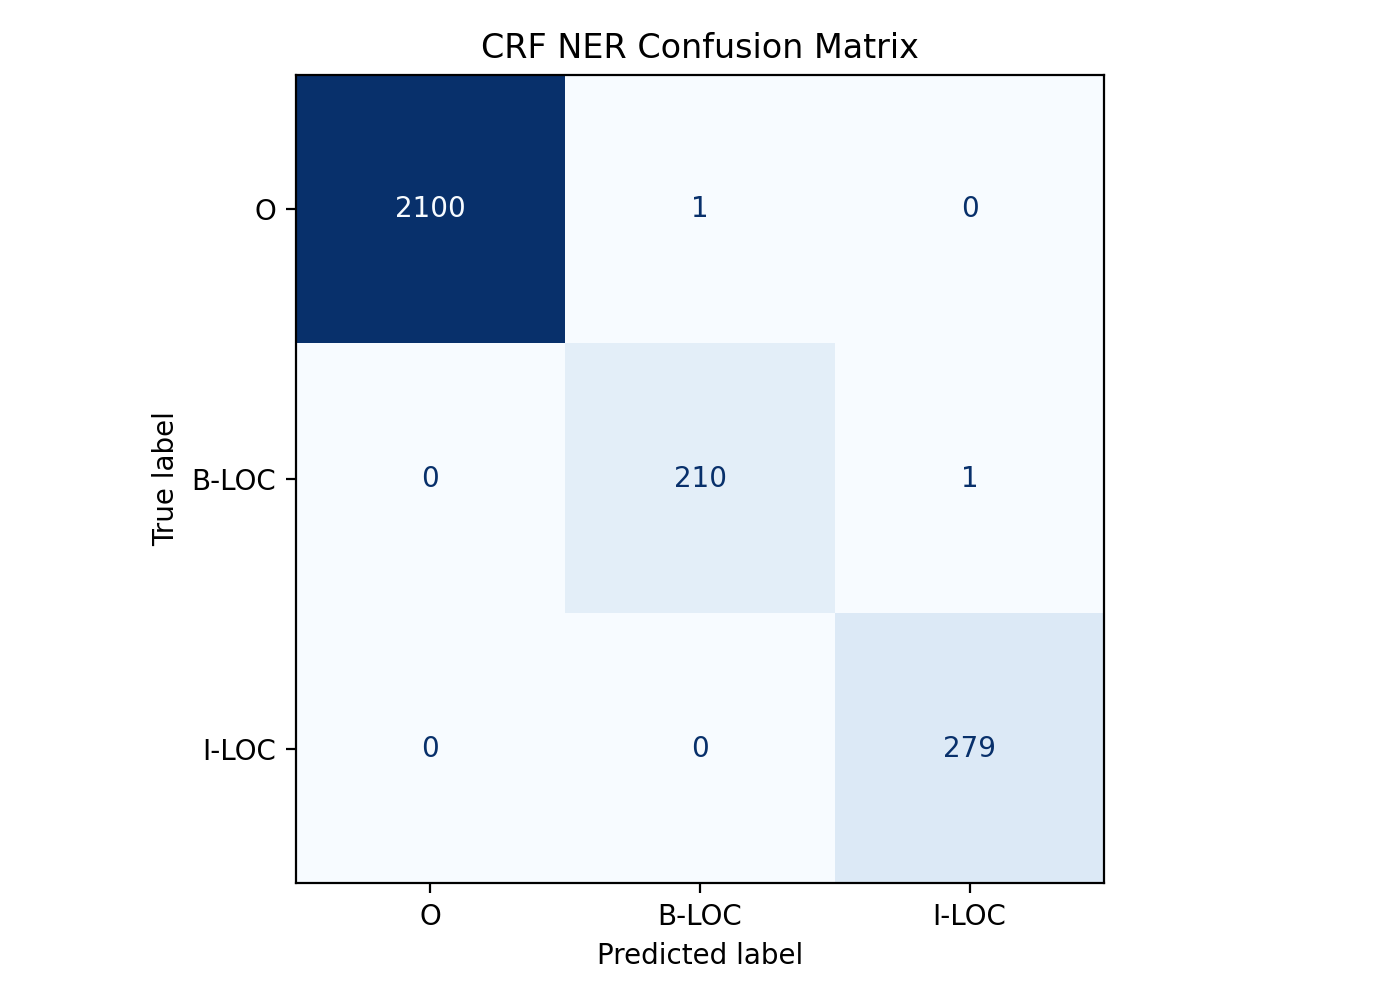

In [47]:
results = train_pipeline(
    dataset_path=DATASET_PATH,
    gazetteer_path=GAZETTEER_PATH,
    output_dir=OUTPUT_DIR,
    augment_from_gazetteer=True,
    random_state=42,
)

print("Classification Report:")
print(results["evaluation"]["classification_report"])
print(f"Accuracy: {results['evaluation']['accuracy']:.4f}")
print(f"Model saved to: {results['model_path']}")
print(f"Confusion matrix saved to: {results['evaluation']['confusion_matrix_path']}")

if Image is not None:
    display(Image(filename=str(results["evaluation"]["confusion_matrix_path"])))



In [48]:
whitebox_test_trace(
    model=results["model"],
    sentence_data="how to enter liyue city",
    gazetteer_names=results["gazetteer_names"],
    gazetteer_tokens=results["gazetteer_tokens"],
    target_t=4,
    target_label="B-LOC"
)


WHITE-BOX TESTING - LinearChainCRF

[1] INISIALISASI DATA
Kalimat masukan (x) : ['how', 'to', 'enter', 'liyue', 'city']
Panjang kalimat (T) : 5
Target kata yang dibedah (t) : 4
Target label sampel dibedah  : 'B-LOC'

[2] POTENSIAL NODE (phi t(yt, x)) PADA t=4 (kata: 'liyue')
Daftar fitur aktif dan nilai bobot lambda k-nya:
  - bias                          : [O= 2.237, B-LOC=-1.384, I-LOC=-0.853]
  - word.prefix2=li               : [O=-0.554, B-LOC= 0.686, I-LOC=-0.132]
  - word.prefix3=liy              : [O=-0.232, B-LOC= 0.254, I-LOC=-0.022]
  - word.suffix2=ue               : [O= 0.411, B-LOC=-0.116, I-LOC=-0.295]
  - word.suffix3=yue              : [O=-0.232, B-LOC= 0.254, I-LOC=-0.022]
  - postag=JJ                     : [O=-0.383, B-LOC=-0.081, I-LOC= 0.464]
  - postag[:2]=JJ                 : [O=-0.467, B-LOC= 0.134, I-LOC= 0.333]
  - is_in_genshin_map=True        : [O=-1.295, B-LOC= 0.592, I-LOC= 0.703]
  - gazetteer_word_overlap=True   : [O=-1.295, B-LOC= 0.592, I-LOC= 0.703]


## 13. Resolver Acceptance Checks

In [49]:
def print_query_resolution(query_text: str, title: str) -> None:
    resolution = resolve_query_locations(
        query_text,
        results["model"],
        results["gazetteer_names"],
        results["gazetteer_tokens"],
    )

    print(f"\n{title} before inference:", resolution["query"])
    print(f"{title} after tokenization:", resolution["tokens"])
    print(f"{title} CRF tags:", resolution["crf_tags"])
    print(f"{title} exact gazetteer matches:", resolution["exact_matches"])
    print(f"{title} alias matches:", resolution["alias_matches"])
    print(f"{title} CRF spans:", resolution["crf_spans"])
    print(f"{title} structured entities:")
    for entity in resolution["entities"]:
        print(entity)
        if entity.get("fuzzy_corrections"):
            print("  fuzzy corrections:", entity["fuzzy_corrections"])
    print(f"{title} extracted locations:", resolution["resolved_names"])

# ==========================================================
# 1. EXACT MATCHES (Nama Resmi / Sesuai Gazetteer)
# Menguji apakah model mengenali nama baku tanpa perlu alias.
# ==========================================================
print_query_resolution("How to unlock Mondstadt City?", "Exact Match - Simple")
print_query_resolution("Where is The Mausoleum of King Deshret?", "Exact Match - Long Name")
print_query_resolution("How do I get to Central Laboratory Ruins?", "Exact Match - Medium Name")

# ==========================================================
# 2. ALIAS MATCHES (Menggunakan ALIAS_MAP)
# Menguji apakah singkatan dari komunitas berhasil di-mapping ke nama asli.
# ==========================================================
print_query_resolution("how to unlock fri in fontaine?", "Alias Match - Acronym (FRI)")
print_query_resolution("how to go to enka", "Alias Match - Shortened (Enka)")
print_query_resolution("is there a quest for the prison?", "Alias Match - Slang (Prison)")
print_query_resolution("how to enter chasm underground", "Alias Match - Phrasing")
print_query_resolution("guide to unlock nodkrai", "Alias Match - Missing Hyphen")

# ==========================================================
# 3. NOISY & TYPOS (Fuzzy Matching Targets)
# Menguji ketahanan sistem terhadap salah ketik (typo) yang wajar terjadi di Discord.
# ==========================================================
print_query_resolution("how do i reach monstat?", "Typo - Missing letters (Monstat)")
print_query_resolution("unlock fontain research institut", "Typo - Missing 'e' (Fontaine)")
print_query_resolution("where is sumru desert", "Typo - Missing 'e' (Sumeru)")
print_query_resolution("how to enter the piramid", "Typo - 'i' instead of 'y' (Pyramid)")

# ==========================================================
# 4. MULTI-ENTITY QUERIES (Lebih dari 1 Lokasi dalam 1 Chat)
# Menguji apakah CRF bisa men-stabilo lebih dari satu entitas dalam satu kalimat.
# ==========================================================
print_query_resolution("is there a quest connecting liyue harbor and watatsumi island?", "Multi-Entity - Clean")
print_query_resolution("route from mond to liyue", "Multi-Entity - With Alias")
print_query_resolution("How do I enter Mt. Aocang and The Chasm: Underground Mines?", "Multi-Entity - Canonical")
print_query_resolution("difference between vanarana and old vanarana", "Multi-Entity - Overlapping words")

# ==========================================================
# 5. EDGE CASES (Tanda Baca Kritis: Kutip, Hubung, Apostrof)
# Ini ujian sesungguhnya untuk Tokenizer kamu (sesuai instruksi Cursor sebelumnya).
# ==========================================================
print_query_resolution("where is stormterror's lair?", "Edge Case - Apostrophe Possession")
print_query_resolution("how to get to clink-clank krumkake craftshop", "Edge Case - Hyphens")
print_query_resolution("go to mt. yougou", "Edge Case - Period / Abbreviation")
print_query_resolution("unlocking the children of echoes tribe", "Edge Case - Missing Quotes from Natlan")
print_query_resolution("is chemin de l'espoir locked?", "Edge Case - French Apostrophe")

# ==========================================================
# 6. AMBIGUOUS / EXTREME NOISE (Tantangan Ekstrem)
# ==========================================================
print_query_resolution("chasm", "Ambiguous - Single word")
print_query_resolution("how access underground mines in chasm bro pls help", "Extreme Noise - Reversed & Filler Words")

# ==========================================================
# 7. RANDOM & ADVANCED NOISE (Simulasi Chat Discord Asli)
# Menguji ketahanan model terhadap singkatan ekstrim, kata campur, dan konteks aneh.
# ==========================================================
print_query_resolution("is there a teleporter near dornman port", "Random - Newly Released Area")
print_query_resolution("bro how tf do i get inside the big ass pyramid", "Random - Extreme Slang (Pyramid Alias)")
print_query_resolution("can someone carry me in dat narukami shrine domain", "Random - Contextual Noise ('domain')")
print_query_resolution("what quest to unlock seiraimaru boat", "Random - Subarea with descriptive noun ('boat')")
print_query_resolution("where is qingce village man i cant find it", "Random - Frustrated User Text")
print_query_resolution("unlocking the ancient sacred mountain fast", "Random - Trailing Adverb ('fast')")

# ==========================================================
# 8. MULTI-REGION & CONFLICTING WORDS (Tantangan Parsing)
# Menguji apakah model bisa membedakan nama area yang punya kata mirip tapi beda region.
# ==========================================================
print_query_resolution("from mondstat to the chasm maw", "Multi-Region - Typo + Exact")
print_query_resolution("is the dune of magma harder than the dune of elusion", "Comparison - Same prefix 'the dune of'")
print_query_resolution("i hate exploring dragonspine and dragon spine", "Repetition & Spacing Test")
print_query_resolution("where do i find the scions of the canopy and masters of the night-wind", "Multi-Tribe - Natlan Extreme Quotes")
print_query_resolution("how to go from liyue city to sumeru city", "Multi-Entity - 'City' Suffix Match")

# ==========================================================
# 9. PUNCTUATION NIGHTMARES (Ujian Regex & Tokenizer Ekstrem)
# ==========================================================
print_query_resolution("how to enter [the chasm: underground mines]", "Punctuation - Bracketed Input")
print_query_resolution("go to... mt. aocang... then to... mt. hulao", "Punctuation - Ellipses (...) Noise")
print_query_resolution("unlock \"people of the springs\" please!!!", "Punctuation - Excessive Exclamation")
print_query_resolution("is qusayr al-inkhida' hard to explore?", "Punctuation - Trailing Apostrophe Mid-Sentence")
print_query_resolution("guide for chenyu vale: upper vale", "Punctuation - Colon without 'The Chasm'")

# ==========================================================
# 10. SHORT FRAGMENTS & KEYWORD ONLY (Pencarian Malas)
# ==========================================================
print_query_resolution("unlock court of fontaine", "Fragment - Verb + Location")
print_query_resolution("way to dadaupa gorge", "Fragment - Slang phrase")
print_query_resolution("farakhkert unlock", "Fragment - Reversed Verb")
print_query_resolution("how stadium of the sacred flame", "Fragment - Broken Grammar")




Exact Match - Simple before inference: How to unlock Mondstadt City?
Exact Match - Simple after tokenization: ['How', 'to', 'unlock', 'Mondstadt', 'City']
Exact Match - Simple CRF tags: [('How', 'O'), ('to', 'O'), ('unlock', 'O'), ('Mondstadt', 'B-LOC'), ('City', 'I-LOC')]
Exact Match - Simple exact gazetteer matches: ['mondstadt city']
Exact Match - Simple alias matches: []
Exact Match - Simple CRF spans: ['mondstadt city']
Exact Match - Simple structured entities:
{'raw_span': 'mondstadt city', 'resolved_name': 'mondstadt city', 'method': 'exact', 'fuzzy_corrections': []}
Exact Match - Simple extracted locations: ['mondstadt city']

Exact Match - Long Name before inference: Where is The Mausoleum of King Deshret?
Exact Match - Long Name after tokenization: ['Where', 'is', 'The', 'Mausoleum', 'of', 'King', 'Deshret']
Exact Match - Long Name CRF tags: [('Where', 'O'), ('is', 'O'), ('The', 'O'), ('Mausoleum', 'B-LOC'), ('of', 'I-LOC'), ('King', 'I-LOC'), ('Deshret', 'I-LOC')]
Exact Mat

In [50]:
print_query_resolution("How do u get to pirami", "Pertanyaan Random")
print_query_resolution("how to enter liyeu?", "Pertanyaan Random")
print_query_resolution("How to enter monstat?", "Pertanyaan Random")
print_query_resolution("How to enter mt. aocang?", "Pertanyaan Random")
print_query_resolution("How to enter jakarta?", "Pertanyaan Random")


Pertanyaan Random before inference: How do u get to pirami
Pertanyaan Random after tokenization: ['How', 'do', 'u', 'get', 'to', 'pirami']
Pertanyaan Random CRF tags: [('How', 'O'), ('do', 'O'), ('u', 'O'), ('get', 'O'), ('to', 'O'), ('pirami', 'B-LOC')]
Pertanyaan Random exact gazetteer matches: []
Pertanyaan Random alias matches: []
Pertanyaan Random CRF spans: ['pirami']
Pertanyaan Random structured entities:
{'raw_span': 'pirami', 'resolved_name': 'piramida', 'method': 'fuzzy', 'fuzzy_corrections': [{'original': 'pirami', 'corrected': 'piramida', 'distance': 2, 'reason': "Corrected 'pirami' -> 'piramida' (edit distance 2)."}]}
  fuzzy corrections: [{'original': 'pirami', 'corrected': 'piramida', 'distance': 2, 'reason': "Corrected 'pirami' -> 'piramida' (edit distance 2)."}]
Pertanyaan Random extracted locations: ['piramida']

Pertanyaan Random before inference: how to enter liyeu?
Pertanyaan Random after tokenization: ['how', 'to', 'enter', 'liyeu']
Pertanyaan Random CRF tags: [(

## Check for Overfitting / Underfitting

Total data  : 1053 kalimat
Train pool  : 842 kalimat (80%)
Test set    : 211 kalimat (20%, tetap)

  n=   84 (  10%): Train=1.0000 | Test=0.9418 | Gap=0.0582
  n=  168 (  20%): Train=1.0000 | Test=0.9663 | Gap=0.0337
  n=  252 (  30%): Train=1.0000 | Test=0.9699 | Gap=0.0301
  n=  336 (  40%): Train=1.0000 | Test=0.9712 | Gap=0.0288
  n=  421 (  50%): Train=1.0000 | Test=0.9703 | Gap=0.0297
  n=  505 (  60%): Train=1.0000 | Test=0.9735 | Gap=0.0265
  n=  589 (  70%): Train=1.0000 | Test=0.9755 | Gap=0.0245
  n=  673 (  80%): Train=1.0000 | Test=0.9755 | Gap=0.0245
  n=  757 (  90%): Train=0.9991 | Test=0.9937 | Gap=0.0055
  n=  842 ( 100%): Train=0.9992 | Test=0.9947 | Gap=0.0045


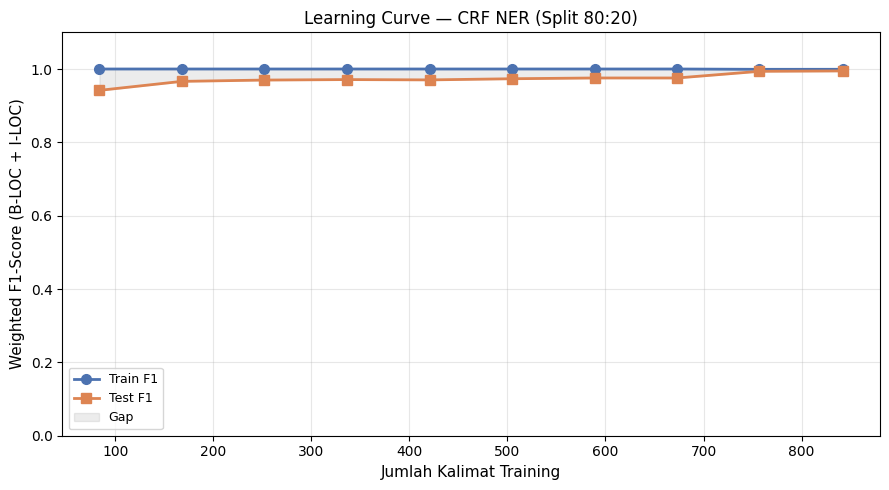


Grafik disimpan ke: d:\Fajrul\Kuliah\Skripsi\Chatbot\outputs\learning_curve_ner.png


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

OUTPUT_DIR.mkdir(exist_ok=True)

_gaz_names  = results["gazetteer_names"]
_gaz_tokens = results["gazetteer_tokens"]

import random as _random
_rng = _random.Random(42)
_shuffled = list(full_augmented)
_rng.shuffle(_shuffled)

_split     = int(len(_shuffled) * 0.8)
_train_pool = _shuffled[:_split]  
_test_sents = _shuffled[_split:]  

_X_te, _y_te = build_feature_matrices(_test_sents, _gaz_names, _gaz_tokens)

print(f"Total data  : {len(_shuffled)} kalimat")
print(f"Train pool  : {len(_train_pool)} kalimat (80%)")
print(f"Test set    : {len(_test_sents)} kalimat (20%, tetap)\n")

_fracs      = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
_train_f1s  = []
_test_f1s   = []
_n_samples  = []

for frac in _fracs:
    n = max(2, int(len(_train_pool) * frac))
    subset = _train_pool[:n]
    X_tr, y_tr = build_feature_matrices(subset, _gaz_names, _gaz_tokens)
    m = train_crf(X_tr, y_tr)
    tr_f1 = f1_score(flatten_labels(y_tr), flatten_labels(m.predict(X_tr)), average="weighted", labels=["B-LOC", "I-LOC"], zero_division=0)
    te_f1 = f1_score(flatten_labels(_y_te), flatten_labels(m.predict(_X_te)), average="weighted", labels=["B-LOC", "I-LOC"], zero_division=0)
    _train_f1s.append(tr_f1)
    _test_f1s.append(te_f1)
    _n_samples.append(n)
    print(f"  n={n:5d} ({frac*100:4.0f}%): Train={tr_f1:.4f} | Test={te_f1:.4f} | Gap={tr_f1 - te_f1:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(_n_samples, _train_f1s, "o-", color="#4C72B0", linewidth=2, markersize=7, label="Train F1")
ax.plot(_n_samples, _test_f1s,  "s-", color="#DD8452", linewidth=2, markersize=7, label="Test F1")
ax.fill_between(
    _n_samples, _train_f1s, _test_f1s,
    alpha=0.15, color="gray", label="Gap"
)

ax.set_xlabel("Jumlah Kalimat Training", fontsize=11)
ax.set_ylabel("Weighted F1-Score (B-LOC + I-LOC)", fontsize=11)
ax.set_title(
    "Learning Curve — CRF NER (Split 80:20)",
    fontsize=12
)
ax.set_ylim(0.0, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()

_save_path = OUTPUT_DIR / "learning_curve_ner.png"
fig.savefig(_save_path, dpi=200)
plt.show()
print(f"\nGrafik disimpan ke: {_save_path}")


